EDA on the Netflix DataSet

Beginner

In [355]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Loading the data and taking a first look(basic inspection)

In [356]:
netflix=pd.read_csv("../data/netflix_data.csv")

In [357]:
netflix.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [358]:
netflix.tail()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,"November 20, 2019",2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a..."
8803,s8804,TV Show,Zombie Dumb,NaN,NaN,NaN,"July 1, 2019",2018,TV-Y7,2 Seasons,"Kids' TV, Korean TV Shows, TV Comedies","While living alone in a spooky town, a young g..."
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,"November 1, 2019",2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,"January 11, 2020",2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero..."
8806,s8807,Movie,Zubaan,Mozez Singh,"Vicky Kaushal, Sarah-Jane Dias, Raaghav Chanan...",India,"March 2, 2019",2015,TV-14,111 min,"Dramas, International Movies, Music & Musicals",A scrappy but poor boy worms his way into a ty...


In [359]:
netflix.shape

(8807, 12)

In [360]:
netflix.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

In [361]:
#Datatype of every column
netflix.dtypes

show_id         object
type            object
title           object
director        object
cast            object
country         object
date_added      object
release_year     int64
rating          object
duration        object
listed_in       object
description     object
dtype: object

In [362]:
#Null Values In Each Column
netflix.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [363]:
#Percentage of director missing
netflix.head(2)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."


In [364]:
#Percentage of director missing
missing_val=netflix['director'].isnull().sum()
total_values=len(netflix['director'])
director_missing_percentage=(missing_val/total_values)*100


In [365]:
print(director_missing_percentage)

29.908027705234474


In [ ]:
#Another method
missing_percentage=netflix['director'].isnull().mean()*100


In [367]:
print(missing_percentage)

29.908027705234474


What percentage of `cast` is missing?

In [368]:
cast_missing_percentage=netflix['cast'].isnull().mean()*100
print(cast_missing_percentage)

9.367548540933349


What percentage of `country` is missing?

In [370]:
country_missing_percentage=netflix['country'].isnull().mean()*100
print(country_missing_percentage)

9.435676166685592


 How many rows have a missing `date_added`, `rating`, or `duration`?

In [371]:
netflix[['date_added','rating','duration']].isnull().any(axis=1).sum()

np.int64(17)

Are there any duplicate `show_id` values?

In [372]:
netflix['show_id'].duplicated().sum()#Means each show id is unique and one id is not repeated anywhere

np.int64(0)

Are there any fully duplicate rows?

In [373]:
netflix.duplicated().sum()

np.int64(0)

Are there any duplicate `title` values?

In [374]:
netflix['title'].duplicated().sum()

np.int64(0)

What is the count of each `type` value (Movie vs. TV Show)?

In [375]:
netflix['type'].value_counts()

type
Movie      6131
TV Show    2676
Name: count, dtype: int64

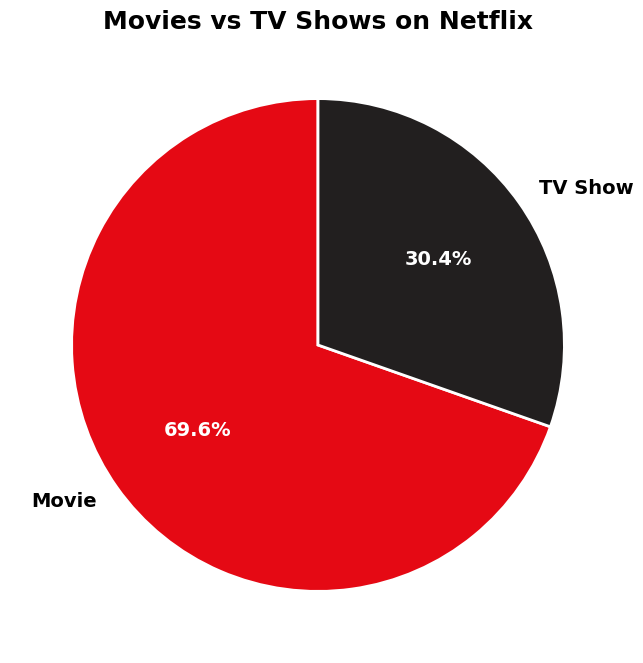

In [465]:
type_counts=netflix['type'].value_counts()
plt.figure(figsize=(8,8))
plt.pie(
    type_counts.values,
    labels=type_counts.index,
    autopct='%1.1f%%',
    colors=['#E50914','#221f1f'],
    startangle=90,
    wedgeprops={'edgecolor':'white','linewidth':2},
    textprops={'color':'white','fontsize':14,'fontweight':'bold'}
)
for label in plt.gca().texts:
    if label.get_text() in type_counts.index:
        label.set_color('black')
plt.title('Movies vs TV Shows on Netflix', fontsize=18, fontweight='bold')
plt.show()

What is the minimum and maximum `release_year`?

In [376]:
min_year=netflix['release_year'].min()
max_year=netflix['release_year'].max()
print(min_year)
print(max_year)

1925
2021


 Print every unique value in the `rating` column.

In [377]:
netflix['rating'].nunique()

17

In [378]:
print(netflix['rating'].unique())

['PG-13' 'TV-MA' 'PG' 'TV-14' 'TV-PG' 'TV-Y' 'TV-Y7' 'R' 'TV-G' 'G'
 'NC-17' '74 min' '84 min' '66 min' 'NR' nan 'TV-Y7-FV' 'UR']


Looking at that list — do any values look out of place for a content-rating column (hint: do any look like a duration instead)?

 Print the full rows where `rating` is one of those odd values — what do you notice about their `duration` column?

In [379]:
netflix[netflix['rating'].isin(['74 min','84 min','66 min'])]



,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
5541,s5542,Movie,Louis C.K. 2017,Louis C.K.,Louis C.K.,United States,"April 4, 2017",2017,74 min,NaN,Movies,"Louis C.K. muses on religion, eternal love, gi..."
5794,s5795,Movie,Louis C.K.: Hilarious,Louis C.K.,Louis C.K.,United States,"September 16, 2016",2010,84 min,NaN,Movies,Emmy-winning comedy writer Louis C.K. brings h...
5813,s5814,Movie,Louis C.K.: Live at the Comedy Store,Louis C.K.,Louis C.K.,United States,"August 15, 2016",2015,66 min,NaN,Movies,The comic puts his trademark hilarious/thought...


What is the count of missing `duration` values, split by `type`?

In [380]:
movies=netflix['type']=="Movie"
tv_shows=netflix['type']=="TV Show"

In [381]:
print(netflix[movies]['duration'].isnull().sum())
print(netflix[tv_shows]['duration'].isnull().sum())

3
0


Correct method to solve this(GROUP BY)

In [382]:
netflix['duration'].isna().groupby(netflix['type']).sum()

type
Movie      3
TV Show    0
Name: duration, dtype: int64

Print a few raw `duration` values for Movies vs. a few for TV Shows — are they even in the same format?

In [383]:
netflix[['type','duration']].groupby('type').head()

,type,duration
0,Movie,90 min
1,TV Show,2 Seasons
2,TV Show,1 Season
3,TV Show,1 Season
4,TV Show,2 Seasons
5,TV Show,1 Season
6,Movie,91 min
7,Movie,125 min
9,Movie,104 min
12,Movie,127 min


Print a few raw `date_added` values — is this stored as text or as an actual date?

In [384]:
netflix[['date_added']].head()

,date_added
0,"September 25, 2021"
1,"September 24, 2021"
2,"September 24, 2021"
3,"September 24, 2021"
4,"September 24, 2021"


Print a few raw `country` values — does any single row contain more than one country?

In [385]:
netflix[['country']].head(20)

,country
0,United States
1,South Africa
2,NaN
3,NaN
4,India
5,NaN
6,NaN
7,"United States, Ghana, Burkina Faso, United Kin..."
8,United Kingdom
9,United States


How many unique raw `country` strings exist, before any splitting?

In [386]:
netflix['country'].nunique()

748

Print a few raw `cast` values — is this a single name, or several names packed into one string?

In [387]:
netflix[['cast']]

,cast
0,NaN
1,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban..."
2,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi..."
3,NaN
4,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K..."
...,...
8802,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J..."
8803,NaN
8804,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ..."
8805,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma..."


Print a few raw `listed_in` values — same comma-separated pattern?

In [388]:
netflix.head(10)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...
5,s6,TV Show,Midnight Mass,Mike Flanagan,"Kate Siegel, Zach Gilford, Hamish Linklater, H...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries",The arrival of a charismatic young priest brin...
6,s7,Movie,My Little Pony: A New Generation,"Robert Cullen, José Luis Ucha","Vanessa Hudgens, Kimiko Glenn, James Marsden, ...",NaN,"September 24, 2021",2021,PG,91 min,Children & Family Movies,Equestria's divided. But a bright-eyed hero be...
7,s8,Movie,Sankofa,Haile Gerima,"Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...","United States, Ghana, Burkina Faso, United Kin...","September 24, 2021",1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies","On a photo shoot in Ghana, an American model s..."
8,s9,TV Show,The Great British Baking Show,Andy Devonshire,"Mel Giedroyc, Sue Perkins, Mary Berry, Paul Ho...",United Kingdom,"September 24, 2021",2021,TV-14,9 Seasons,"British TV Shows, Reality TV",A talented batch of amateur bakers face off in...
9,s10,Movie,The Starling,Theodore Melfi,"Melissa McCarthy, Chris O'Dowd, Kevin Kline, T...",United States,"September 24, 2021",2021,PG-13,104 min,"Comedies, Dramas",A woman adjusting to life after a loss contend...


In [389]:
netflix[['listed_in']].head()

,listed_in
0,Documentaries
1,"International TV Shows, TV Dramas, TV Mysteries"
2,"Crime TV Shows, International TV Shows, TV Act..."
3,"Docuseries, Reality TV"
4,"International TV Shows, Romantic TV Shows, TV ..."


#🟡 INTERMEDIATE — Cleaning, Parsing & Aggregation

 Fix the 3 misplaced `rating` rows from Beginner — move the duration value into `duration` and set `rating` to a proper missing value. What's your justification for not just dropping these 3 rows?

In [390]:
netflix[netflix['rating'].isin(['74 min','84 min','66 min'])]

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
5541,s5542,Movie,Louis C.K. 2017,Louis C.K.,Louis C.K.,United States,"April 4, 2017",2017,74 min,NaN,Movies,"Louis C.K. muses on religion, eternal love, gi..."
5794,s5795,Movie,Louis C.K.: Hilarious,Louis C.K.,Louis C.K.,United States,"September 16, 2016",2010,84 min,NaN,Movies,Emmy-winning comedy writer Louis C.K. brings h...
5813,s5814,Movie,Louis C.K.: Live at the Comedy Store,Louis C.K.,Louis C.K.,United States,"August 15, 2016",2015,66 min,NaN,Movies,The comic puts his trademark hilarious/thought...


In [391]:
mask=netflix['rating'].isin(['74 min','84 min','66 min'])

In [392]:
netflix.loc[mask,'rating']

5541    74 min
5794    84 min
5813    66 min
Name: rating, dtype: object

In [393]:
netflix.loc[mask,'duration']

5541    NaN
5794    NaN
5813    NaN
Name: duration, dtype: object

In [394]:
netflix.loc[mask,'duration']=netflix.loc[mask,'rating']

In [395]:
netflix.loc[mask,'rating']=np.nan

In [396]:
netflix[mask]

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
5541,s5542,Movie,Louis C.K. 2017,Louis C.K.,Louis C.K.,United States,"April 4, 2017",2017,NaN,74 min,Movies,"Louis C.K. muses on religion, eternal love, gi..."
5794,s5795,Movie,Louis C.K.: Hilarious,Louis C.K.,Louis C.K.,United States,"September 16, 2016",2010,NaN,84 min,Movies,Emmy-winning comedy writer Louis C.K. brings h...
5813,s5814,Movie,Louis C.K.: Live at the Comedy Store,Louis C.K.,Louis C.K.,United States,"August 15, 2016",2015,NaN,66 min,Movies,The comic puts his trademark hilarious/thought...


Convert `date_added` into a proper datetime column — does it parse cleanly afterward?

In [397]:
#pd.to_datetime(netflix['date_added'])

In [398]:
netflix['date_added']=netflix['date_added'].str.strip()

In [399]:
netflix['date_added']=pd.to_datetime(netflix['date_added'])

In [400]:
netflix['date_added'].head()

0   2021-09-25
1   2021-09-24
2   2021-09-24
3   2021-09-24
4   2021-09-24
Name: date_added, dtype: datetime64[ns]

 Which single country appears most often after splitting?

In [457]:
netflix.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,genre
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",Documentaries
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",International TV Shows
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,Crime TV Shows
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",Docuseries
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,International TV Shows


In [459]:
countries=netflix['country'].dropna().str.split(',')
countries=countries.explode()
countries=countries.str.strip()

In [461]:
print(countries.value_counts().head())

country
United States     3690
India             1046
United Kingdom     806
Canada             445
France             393
Name: count, dtype: int64


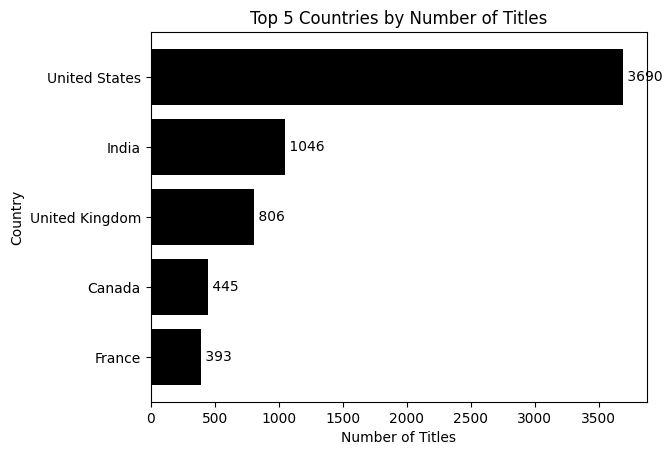

In [464]:
top5_countries=countries.value_counts().head()
bars=plt.barh(top5_countries.index, top5_countries.values, color='black')
plt.xlabel('Number of Titles')
plt.ylabel('Country')
plt.title('Top 5 Countries by Number of Titles')
plt.gca().invert_yaxis()
for bar in bars:
    width=bar.get_width()
    plt.text(width, bar.get_y()+bar.get_height()/2, f' {int(width)}', va='center')
plt.show()

Split `listed_in` into individual genres — which 10 genres appear most frequently?

In [ ]:
netflix.head(5)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,genre
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",Documentaries
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",International TV Shows
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,Crime TV Shows
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",Docuseries
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,International TV Shows


In [413]:
netflix['genre']=netflix['listed_in'].str.split(',').str[0]

In [454]:
netflix.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,genre
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",Documentaries
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",International TV Shows
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,Crime TV Shows
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",Docuseries
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,International TV Shows


In [ ]:
#Top 5 Genres that appear most
netflix['genre'].value_counts().head()

genre
Dramas                    1600
Comedies                  1210
Action & Adventure         859
Documentaries              829
International TV Shows     774
Name: count, dtype: int64

In [556]:

genre_exploded = netflix['listed_in'].str.split(',')
genre_exploded = genre_exploded.explode()
genre_exploded= genre_exploded.str.strip()

genre_exploded.value_counts().head()

listed_in
International Movies      2752
Dramas                    2427
Comedies                  1674
International TV Shows    1351
Documentaries              869
Name: count, dtype: int64

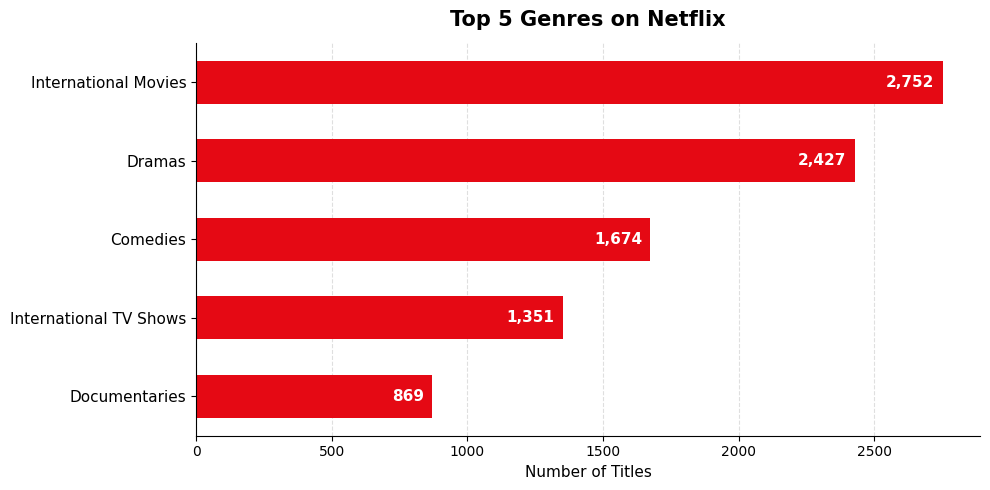

In [558]:

top5_genres = genre_exploded.value_counts().head().sort_values()

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(top5_genres.index, top5_genres.values, color='#E50914', height=0.55)

for bar in bars:
    width = bar.get_width()
    ax.text(width - 30, bar.get_y() + bar.get_height() / 2,
            f'{int(width):,}', va='center', ha='right', fontsize=11, fontweight='bold', color='white')

ax.set_xlabel('Number of Titles', fontsize=11)
ax.set_title('Top 5 Genres on Netflix', fontsize=15, fontweight='bold', pad=12)
ax.spines[['top', 'right']].set_visible(False)
ax.tick_params(axis='y', labelsize=11)
ax.xaxis.grid(True, linestyle='--', alpha=0.4)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()


Split `cast` into individual actor names — which actor appears in the most titles?

In [421]:
splitted_cast=netflix['cast'].dropna().str.split(',')

all_actors=splitted_cast.explode()

all_actors=all_actors.str.strip()

print(all_actors.value_counts().head())


cast
Anupam Kher         43
Shah Rukh Khan      35
Julie Tejwani       33
Takahiro Sakurai    32
Naseeruddin Shah    32
Name: count, dtype: int64


Which director appears in the most titles (ignoring missing values)?

In [430]:
directors=netflix['director' ].dropna()
print(directors.value_counts().head())

director
Rajiv Chilaka             19
Raúl Campos, Jan Suter    18
Suhas Kadav               16
Marcus Raboy              16
Jay Karas                 14
Name: count, dtype: int64


 Some directors are comma-separated combos, which inflates/misrepresents individual counts.

In [428]:
splitted_director=netflix['director'].dropna().str.split(',')

all_directors=splitted_director.explode()

all_directors=all_directors.str.strip()

In [ ]:
print(all_directors.value_counts().head())
#Now these are the correct results 

director
Rajiv Chilaka    22
Jan Suter        21
Raúl Campos      19
Marcus Raboy     16
Suhas Kadav      16
Name: count, dtype: int64


For Movies only, extract a numeric minutes column from `duration` — what's the average movie length?

In [442]:
movies_only=netflix[netflix['type']=='Movie']
movies_only['duration_mins']=movies_only['duration'].str.replace(' min','',regex=False).astype(int)


C:\Users\Arnav pareek\AppData\Local\Temp\ipykernel_27328\323965217.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  movies_only['duration_mins']=movies_only['duration'].str.replace(' min','',regex=False).astype(int)


In [443]:
avg_movie_length=movies_only['duration_mins'].mean()
print(avg_movie_length)

99.56499755341706


 For TV Shows only, extract a numeric "number of seasons" column from `duration` — what's the average number of seasons?

In [444]:
netflix.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,genre
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",Documentaries
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",International TV Shows
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,Crime TV Shows
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",Docuseries
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,International TV Shows


In [445]:
tv_shows_only=netflix[netflix['type']=="TV Show"]

In [449]:
tv_shows_only['number_of_seasons']=tv_shows_only['duration'].str.replace(' Seasons?','',regex=True).astype(int)

C:\Users\Arnav pareek\AppData\Local\Temp\ipykernel_27328\124830247.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tv_shows_only['number_of_seasons']=tv_shows_only['duration'].str.replace(' Seasons?','',regex=True).astype(int)


In [451]:
tv_shows_only[['number_of_seasons']]

,number_of_seasons
1,2
2,1
3,1
4,2
5,1
...,...
8795,2
8796,2
8797,3
8800,1


In [452]:
avg_seasons=tv_shows_only['number_of_seasons'].mean()
print(avg_seasons)

1.764947683109118


Count titles by `release_year` — which year had the most titles originally released?

In [471]:
netflix['release_year'].mode()

0    2018
Name: release_year, dtype: int64

In [473]:
year=netflix[netflix['release_year']==2018]

In [477]:
#To count total no of titles(Count the no total no of rows as that wil be the ans)
year.shape[0]

1147

In [ ]:
#Other way of doing the same thing
netflix['release_year'].value_counts().head()

release_year
2018    1147
2017    1032
2019    1030
2020     953
2016     902
Name: count, dtype: int64

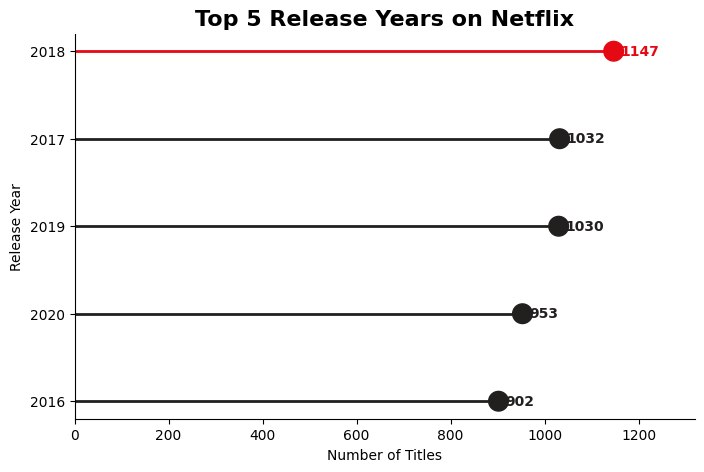

In [491]:
top5_years=netflix['release_year'].value_counts().head().sort_values()
colors=['#221f1f' if y!=2018 else '#E50914' for y in top5_years.index]

fig,ax=plt.subplots(figsize=(8,5))
ax.hlines(y=top5_years.index.astype(str), xmin=0, xmax=top5_years.values, color=colors, linewidth=2)
ax.scatter(top5_years.values, top5_years.index.astype(str), color=colors, s=200, zorder=3)

for year,count,color in zip(top5_years.index.astype(str), top5_years.values, colors):
    ax.text(count+15, year, str(count), va='center', fontweight='bold', color=color)

ax.set_xlabel('Number of Titles')
ax.set_ylabel('Release Year')
ax.set_title('Top 5 Release Years on Netflix', fontsize=16, fontweight='bold')
ax.set_xlim(0, top5_years.max()*1.15)
ax.spines[['top','right']].set_visible(False)
plt.show()

Count titles by the year they were *added* to Netflix (from `date_added`) — which year saw the most additions?

In [ ]:
netflix['date_added'].value_counts().head()#Wrong as this is not by year

date_added
2020-01-01    110
2019-11-01     91
2018-03-01     75
2019-12-31     74
2018-10-01     71
Name: count, dtype: int64

In [ ]:
#Correct method(Seperate year from the dates)
netflix['year_added']=netflix['date_added'].dt.year

In [487]:
netflix['year_added'].value_counts().head()

year_added
2019.0    2016
2020.0    1879
2018.0    1649
2021.0    1498
2017.0    1188
Name: count, dtype: int64

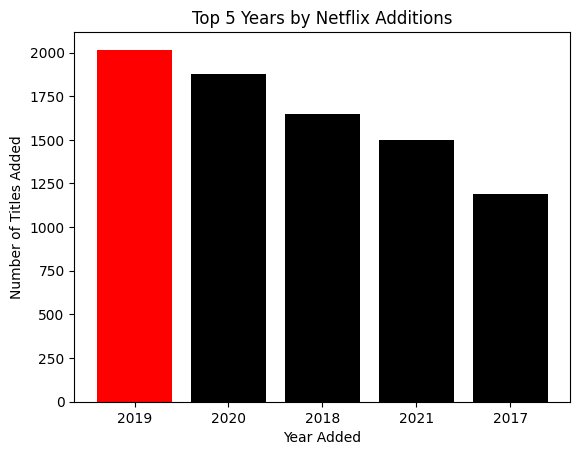

In [490]:
top5_added=netflix['year_added'].value_counts().head()
colors=['red' if year==2019 else 'black' for year in top5_added.index]

plt.bar(top5_added.index.astype(int).astype(str), top5_added.values, color=colors)
plt.xlabel('Year Added')
plt.ylabel('Number of Titles Added')
plt.title('Top 5 Years by Netflix Additions')
plt.show()

Create a new column: `years_between_release_and_addition` = (year added − `release_year`). What's the average gap?

In [492]:
netflix.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,genre,year_added
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",Documentaries,2021.0
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",International TV Shows,2021.0
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,Crime TV Shows,2021.0
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",Docuseries,2021.0
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,International TV Shows,2021.0


In [496]:
netflix['years_gap_between_realease_and_addition']=netflix['year_added']-netflix['release_year']

In [497]:
netflix[['years_gap_between_realease_and_addition']].head()

,years_gap_between_realease_and_addition
0,1.0
1,0.0
2,0.0
3,0.0
4,0.0


In [499]:
print("Average Gap:",netflix['years_gap_between_realease_and_addition'].mean())

Average Gap: 4.688416505626918


Are there any rows where the year added is *earlier* than `release_year`? What would that mean, and how many rows have it?

In [514]:
netflix[netflix['years_gap_between_realease_and_addition']<0]

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,genre,year_added,years_gap_between_realease_and_addition
1551,s1552,TV Show,Hilda,NaN,"Bella Ramsey, Ameerah Falzon-Ojo, Oliver Nelso...","United Kingdom, Canada, United States",2020-12-14,2021,TV-Y7,2 Seasons,Kids' TV,"Fearless, free-spirited Hilda finds new friend...",Kids' TV,2020.0,-1.0
1696,s1697,TV Show,Polly Pocket,NaN,"Emily Tennant, Shannon Chan-Kent, Kazumi Evans...","Canada, United States, Ireland",2020-11-15,2021,TV-Y,2 Seasons,Kids' TV,After uncovering a magical locket that allows ...,Kids' TV,2020.0,-1.0
2920,s2921,TV Show,Love Is Blind,NaN,"Nick Lachey, Vanessa Lachey",United States,2020-02-13,2021,TV-MA,1 Season,"Reality TV, Romantic TV Shows",Nick and Vanessa Lachey host this social exper...,Reality TV,2020.0,-1.0
3168,s3169,TV Show,Fuller House,NaN,"Candace Cameron Bure, Jodie Sweetin, Andrea Ba...",United States,2019-12-06,2020,TV-PG,5 Seasons,TV Comedies,The Tanner family’s adventures continue as DJ ...,TV Comedies,2019.0,-1.0
3287,s3288,TV Show,Maradona in Mexico,NaN,Diego Armando Maradona,"Argentina, United States, Mexico",2019-11-13,2020,TV-MA,1 Season,"Docuseries, Spanish-Language TV Shows","In this docuseries, soccer great Diego Maradon...",Docuseries,2019.0,-1.0
3369,s3370,TV Show,BoJack Horseman,NaN,"Will Arnett, Aaron Paul, Amy Sedaris, Alison B...",United States,2019-10-25,2020,TV-MA,6 Seasons,TV Comedies,Meet the most beloved sitcom horse of the '90s...,TV Comedies,2019.0,-1.0
3433,s3434,TV Show,The Hook Up Plan,NaN,"Marc Ruchmann, Zita Hanrot, Sabrina Ouazani, J...",France,2019-10-11,2020,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...","When Parisian Elsa gets hung up on her ex, her...",International TV Shows,2019.0,-1.0
4844,s4845,TV Show,Unbreakable Kimmy Schmidt,NaN,"Ellie Kemper, Jane Krakowski, Tituss Burgess, ...",United States,2018-05-30,2019,TV-14,4 Seasons,TV Comedies,When a woman is rescued from a doomsday cult a...,TV Comedies,2018.0,-1.0
4845,s4846,TV Show,Arrested Development,NaN,"Jason Bateman, Portia de Rossi, Will Arnett, M...",United States,2018-05-29,2019,TV-MA,5 Seasons,TV Comedies,It's the Emmy-winning story of a wealthy famil...,TV Comedies,2018.0,-1.0
5394,s5395,Movie,Hans Teeuwen: Real Rancour,Doesjka van Hoogdalem,Hans Teeuwen,Netherlands,2017-07-01,2018,TV-MA,86 min,Stand-Up Comedy,Comedian Hans Teeuwen rebels against political...,Stand-Up Comedy,2017.0,-1.0


In [515]:
#How many rows have it
len(netflix[netflix['years_gap_between_realease_and_addition']<0])

14

What is the single most common `rating` value overall?

In [517]:
netflix['rating'].value_counts().head()

rating
TV-MA    3207
TV-14    2160
TV-PG     863
R         799
PG-13     490
Name: count, dtype: int64

In [516]:
#Most common rating(mode)
netflix['rating'].mode()

0    TV-MA
Name: rating, dtype: object

How does the Movie vs. TV Show split differ across the top 5 countries?

In [521]:
countries.value_counts().head()

country
United States     3690
India             1046
United Kingdom     806
Canada             445
France             393
Name: count, dtype: int64

In [525]:
netflix_exploded=netflix.copy()

In [526]:
netflix_exploded['country'] = netflix_exploded['country'].dropna().str.split(',')
netflix_exploded = netflix_exploded.explode('country')
netflix_exploded['country'] = netflix_exploded['country'].str.strip()

In [533]:
top5=countries.value_counts().head().index.to_list()


In [535]:
netflix_exploded[netflix_exploded['country'].isin(top5)].groupby('country')['type'].value_counts()

country         type   
Canada          Movie       319
                TV Show     126
France          Movie       303
                TV Show      90
India           Movie       962
                TV Show      84
United Kingdom  Movie       534
                TV Show     272
United States   Movie      2752
                TV Show     938
Name: count, dtype: int64

Which genre (from `listed_in`) is most associated with TV Shows? Which is most associated with Movies?

In [548]:
netflix_genre_exploded = netflix.copy()
netflix_genre_exploded['genre'] = netflix_genre_exploded['listed_in'].str.split(',')
netflix_genre_exploded = netflix_genre_exploded.explode('genre')
netflix_genre_exploded['genre'] = netflix_genre_exploded['genre'].str.strip()

netflix_genre_exploded.groupby('type')['genre'].value_counts().groupby(level=0).head(1)

type     genre                 
Movie    International Movies      2752
TV Show  International TV Shows    1351
Name: count, dtype: int64

C:\Users\Arnav pareek\AppData\Local\Temp\ipykernel_27328\945580766.py:43: UserWarning: Glyph 127916 (\N{CLAPPER BOARD}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Arnav pareek\AppData\Local\Temp\ipykernel_27328\945580766.py:43: UserWarning: Glyph 128250 (\N{TELEVISION}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Arnav pareek\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127916 (\N{CLAPPER BOARD}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Arnav pareek\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128250 (\N{TELEVISION}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


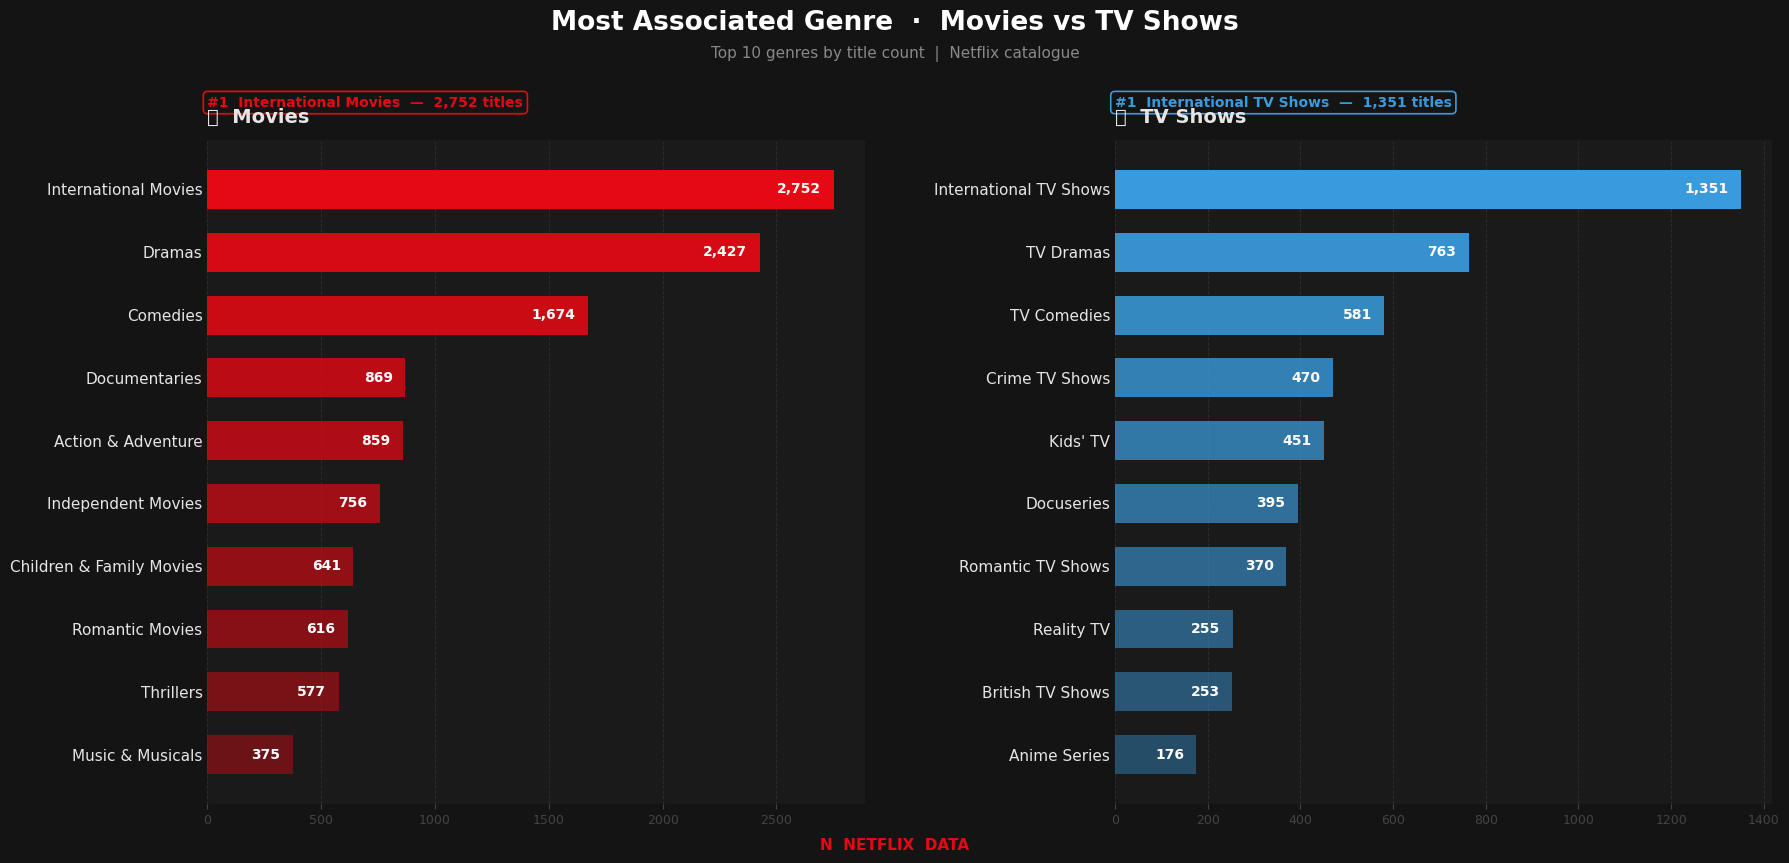

In [557]:

# Genre counts split by type — same explode approach as above cell
genres = netflix.assign(genre=netflix['listed_in'].str.split(',')).explode('genre')
genres['genre'] = genres['genre'].str.strip()

genre_counts = genres.groupby('type')['genre'].value_counts()
movie_genres = genre_counts['Movie'].head(10).sort_values()
tv_genres    = genre_counts['TV Show'].head(10).sort_values()

DARK, RED, BLUE, LIGHT = '#141414', '#E50914', '#3a9bdc', '#e5e5e5'

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8), facecolor=DARK)

for ax, data, color, label in [
    (ax1, movie_genres, RED,  '🎬  Movies'),
    (ax2, tv_genres,    BLUE, '📺  TV Shows'),
]:
    ax.set_facecolor('#1a1a1a')
    for sp in ax.spines.values(): sp.set_visible(False)

    alphas = [0.4 + 0.6 * (i / (len(data) - 1)) for i in range(len(data))]
    bars = ax.barh(range(len(data)), data.values, height=0.62, color=color)
    for bar, a in zip(bars, alphas): bar.set_alpha(a)

    for bar, val in zip(bars, data.values):
        ax.text(val - data.max() * 0.02, bar.get_y() + bar.get_height() / 2,
                f'{val:,}', va='center', ha='right', fontsize=10, fontweight='bold', color='white')

    ax.set_yticks(range(len(data)))
    ax.set_yticklabels(data.index, fontsize=11, color=LIGHT)
    ax.tick_params(axis='x', colors='#444', labelsize=9)
    ax.tick_params(axis='y', length=0)
    ax.xaxis.grid(True, color='#2b2b2b', linewidth=0.7, linestyle='--')
    ax.set_axisbelow(True)
    ax.set_title(label, color=LIGHT, fontsize=14, fontweight='bold', loc='left', pad=12)
    ax.annotate(f'#1  {data.index[-1]}  —  {data.values[-1]:,} titles',
                xy=(0, 1.05), xycoords='axes fraction', fontsize=10, color=color,
                fontweight='bold', bbox=dict(boxstyle='round,pad=0.3', fc=DARK, ec=color, lw=1.2))

fig.suptitle('Most Associated Genre  ·  Movies vs TV Shows', color='white', fontsize=19, fontweight='bold', y=1.04)
fig.text(0.5, 0.98, 'Top 10 genres by title count  |  Netflix catalogue', ha='center', fontsize=11, color='#888')
fig.text(0.5, -0.01, 'N  NETFLIX  DATA', ha='center', fontsize=11, color=RED, fontweight='bold')

plt.tight_layout()
plt.subplots_adjust(wspace=0.38)
plt.show()
